# Clase 03: Orquestación inteligente de agentes con LangGraph

## Recuperando lo realizado en Clase 02

### Agregar API KEY en variables de entorno

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

### Imports

In [ ]:
#from time import sleep

from google import genai
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import (ChatGoogleGenerativeAI,
                                    GoogleGenerativeAIEmbeddings)
from langchain_text_splitters import RecursiveCharacterTextSplitter

### Pasos realizados en Clase 01

In [3]:
# Carga de los documentos

documentos = []

for root,_,files in os.walk("data/Clase_01: Assets Inmersión/"):
	for f in files:
		if not f.endswith(".pdf"):
			continue

		ruta = os.path.join(root, f)
		loader = PyPDFLoader(ruta)
		paginas = loader.load()
		documentos.extend(paginas)

# Creación de los fragmentos

divisor = RecursiveCharacterTextSplitter(
	chunk_size=400, # Tamaño del fragmento
	chunk_overlap=40, # Superposicion de los fragmentos
	separators=["\n\n", "\n", ". ", " ", ""]
)


fragmentos = divisor.split_documents(documentos)

# Instancia de embeddings

 # Dependiendo del framework que uses para crear los embeddings, la forma difiere

embeddings = GoogleGenerativeAIEmbeddings(
	model="models/gemini-embedding-001"
)

# Creación del Vector Store

# sleep(61)

# vectorstore1 = FAISS.from_documents(
# 	documents=fragmentos[0:89],
# 	embedding=embeddings
# )

# sleep(61)

# vectorstore2 = FAISS.from_documents(
# 	documents=fragmentos[90:],
# 	embedding=embeddings
# )

# sleep(61)

# vectorstore1.merge_from(vectorstore2)

	# Se cargó tarjeta de crédito.

vectorstore1 = FAISS.from_documents(
	documents=fragmentos,
	embedding=embeddings
)


# Ensamblado

	# Instancia del LLM

llm = ChatGoogleGenerativeAI(
	model="gemini-2.5-flash",
	temperature=0.2
)


	# Instancia de recuperador

retriever = vectorstore1.as_retriever(
	search_kwargs={
		"k" : 4
	}
)
	#Ensamble

def preguntar_rag(pregunta):
	"""Busca contexto relevante en los documentos y genera una respuesta."""
	# Paso 1: Buscar los chunks más relevantes
	docs = retriever.invoke(pregunta)
	contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

	# Paso 2: Construir el prompt con el contexto encontrado
	prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
	en el contexto proporcionado. Si la información no está en el contexto,
	di que no tienes suficiente información.

	Contexto: {contexto}

	Pregunta: {pregunta}

	Respuesta:"""

	# Paso 3: Enviar al modelo y devolver la respuesta
	#sleep(2)
	respuesta = llm.invoke(prompt)
	#sleep(2)

	return respuesta.content

### Ejemplo

In [4]:
#sleep(61)

In [5]:
preguntar_rag("Donde se mantuvo concentrado el mix de productos?")

'Según el contexto proporcionado:\n\n*   El portafolio se concentró en el Circuito Clásico y la Escapada Estambul.\n*   Para los reportes trimestrales Q2, Q3 y Q4 de 2025, el mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

## Comienzo de clase: Creación del grafo para el Workflow del agente de AI

Se instalarán los siguientes paquetes:
 * `langgraph`: Extensión de LangChain, diseñada para construir agentes de IA sofisticados, con estado y cíclicos.
 * `google-search-results`: En Python es un paquete o biblioteca, frecuentemente asociado a SerpApi, diseñado para extraer y analizar resultados de búsqueda de Google (SERP) de forma automatizada y estructurada. 
 * `markdown` : Es una biblioteca (o lenguaje de marcado ligero) utilizada para convertir texto plano con formato simple en HTML legible.
 * `fpdf2` : Es una biblioteca de Python, de código abierto y fácil de usar, diseñada para crear documentos PDF de forma programática.

 ### Diagrama del grafo a construir

```
                          ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente/Router]                                        → [Generar Markdown] → END
                          └─── "web" ───→ [Buscar en la web] ───────┘
```

### Importar SerpAI

In [6]:
from langchain_community.utilities import SerpAPIWrapper

buscador = SerpAPIWrapper()
buscador.run("Cual es el ganador del último mundial de karate?")

"['El Campeonato Mundial de Karate es el principal torneo de karate en el mundo organizado por la Federación Mundial de Karate.\\u200b Se realiza desde 1970 y ...', 'ISHIBASHI SAORI - JAPAN; 1. MIZUKAMI CHIHO - JAPAN; 1. TAIRA SAE - JAPAN; 2. D ONOFRIO TERRYANA - ITALY; 2. RIZZO MICHELA - ITALY; 2.', 'Nicolás Valdivia se coronó campeón de la International Karate Federation en Tokio, Japón. El karateca chileno venció a un representante ...', '¿Qué hay detrás de un título mundial? En este episodio conversamos con Rodrigo Rojas, campeón mundial de karate, quien comparte su historia ...', 'Final Kumite Equipos Chile vs Japón | Funakoshi Gichin Cup 16th Karate World Championship Tournament. Canal Oficial JKA Chile Karate Tradicional ...', 'Egipto logró su primer título mundial en el equipo masculino Kumite, derrotando a la República Islámica de Irán por 3-0 en una final dominante.', 'Se quedó con el título tras vencer a un representante local. Chileno Nicolás Valdivia se coronó campeón mund

### Creación del objeto AgentState

In [7]:
from typing import TypedDict

from langgraph.graph import END, START, StateGraph


class AgentState(TypedDict):
	pregunta : str
	fuente : str
	contexto : str
	respuesta : str

### Creación de las funciones para los nodos y las condicionales

In [14]:
def nodo_agente(state : AgentState):
	pregunta = state["pregunta"]

	prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
	responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
	informaciones más generales en la WEB (internet).
	Reglas:
	- Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
	- Responde SOLO con la palabra 'WEB' si la pregunta requiere información actualizada, de temas generales, de la web

	Pregunta: {pregunta}

	Respuesta (RAG o Web):
	"""
	#sleep(2)
	respuesta = llm.invoke(prompt)
	#sleep(2)
	fuente = respuesta.content.strip()

	if "rag" in fuente.lower():
		fuente = "RAG"
	else:
		fuente = "WEB"

	print(f"El agente decidió '{fuente}'")

	return {
		"fuente" : fuente
	}


def nodo_rag(state : AgentState):
	contexto = preguntar_rag(state["pregunta"])

	return {
		"contexto" : contexto
	}


def nodo_web(state : AgentState):
	contexto = buscador.run(state["pregunta"])

	return {
		"contexto" : contexto
	}

def nodo_markdown(state : AgentState):
	prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
	formateada en Markdown basándote en el contexto proporcionado.

	Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
	Responde siempre en español.

	Contexto (fuente: {state["fuente"]}):
	{state["contexto"]}

	Pregunta: {state["pregunta"]}

	Respuesta en Markdown:"""
	#sleep(2)
	respuesta = llm.invoke(prompt)
	#sleep(2)
	return {
		"respuesta" : respuesta.content
	}

def decidir_fuente(state : AgentState):

	if state["fuente"] == "RAG":
		return "RAG_elegido"
	elif state["fuente"] == "WEB":
		return "WEB_elegido"
	else:
		return "ERROR"

### Construcción del grafo

In [15]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("WEB", nodo_web)
grafo.add_node("Markdown", nodo_markdown)


grafo.add_edge(START, "Agente")
grafo.add_conditional_edges(
	"Agente", decidir_fuente,
	{"RAG_elegido": "RAG", "WEB_elegido":"WEB"}
)

grafo.add_edge("RAG", "Markdown")
grafo.add_edge("WEB", "Markdown")
grafo.add_edge("Markdown", END)


### Compilación del grafo

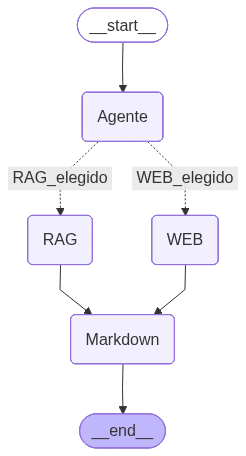

In [16]:
agente = grafo.compile()
agente

### Ejecución del agente workflow y algunos ejemplo

In [17]:
def ejecutar_agente(pregunta):

	resultado = agente.invoke(
		{
			"pregunta" : pregunta,
			"fuente" : "",
			"contexto" : "",
			"respuesta" : "",
		}
	)

	respuesta_final = resultado["respuesta"]

	print("*" * 60, "\n\n")
	print(f"Fuente utilizada:\n\n {resultado["fuente"]}")
	print("\n\n", "*" * 60, "\n\n")
	print(f"Contexto utilizado:\n\n {resultado["contexto"]}")
	print("\n\n", "*" * 60, "\n\n")
	print(f"Respuesta final:\n\n {respuesta_final}")
	print("\n\n")

	return respuesta_final

In [18]:
#sleep(61)

In [19]:
ejecutar_agente("Donde se mantuvo concentrado el mix de productos?")

El agente decidió 'RAG'
************************************************************ 


Fuente utilizada:

 RAG


 ************************************************************ 


Contexto utilizado:

 El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).


 ************************************************************ 


Respuesta final:

 # Concentración del Mix de Productos

## Análisis de la Estrategia de Producto

Según la información proporcionada, el mix de productos mantuvo una clara concentración en un tipo específico de oferta.

## Detalle de la Concentración del Mix de Productos

El mix de productos se mantuvo **concentrado** en la siguiente categoría:

*   **Circuitos combinados**

Estos circuitos combinados incluían destinos específicos, que eran:

*   **Estambul**
*   **Capadocia**

Por lo tanto, la concentración del mix de productos se mantuvo en los **circuitos combinados que integraban Estambul y Capadocia**.





'# Concentración del Mix de Productos\n\n## Análisis de la Estrategia de Producto\n\nSegún la información proporcionada, el mix de productos mantuvo una clara concentración en un tipo específico de oferta.\n\n## Detalle de la Concentración del Mix de Productos\n\nEl mix de productos se mantuvo **concentrado** en la siguiente categoría:\n\n*   **Circuitos combinados**\n\nEstos circuitos combinados incluían destinos específicos, que eran:\n\n*   **Estambul**\n*   **Capadocia**\n\nPor lo tanto, la concentración del mix de productos se mantuvo en los **circuitos combinados que integraban Estambul y Capadocia**.'

In [20]:
#sleep(30)

In [21]:
reporte = ejecutar_agente("En cuales mundiales México ha avanzado más en el torneo?")
reporte

El agente decidió 'WEB'
************************************************************ 


Fuente utilizada:

 WEB


 ************************************************************ 


Contexto utilizado:

 ['La selección de fútbol de México ha estado presente en diecisiete ediciones de la Copa Mundial de Fútbol, siendo el quinto representativo nacional con más ...', 'México jugó 17 Mundiales a lo largo de su historia y el de 2026 será el 18°. El Tri no falta a la Copa del Mundo desde Estados Unidos 1994 y ...', 'A lo largo de sus 16 participaciones, México ha anotado más de 50 goles en Copas del Mundo. Algunos de los goles más memorables incluyen el gol ...', 'La Tri es uno de los seleccionados con más Copas jugadas, ya que solo es superada por Alemania, Brasil, Italia y Argentina. Sus mejores ...', 'Bélgica 1-2 México - Mundial México 1986 – Fase de Grupos (Grupo B) : Martes 3 de junio de 1986 🏟️: Estadio Azteca, Ciudad de México ...', 'Dos ediciones en cuartos de final, alcanzados en Méxi

'# Participaciones Destacadas de México en la Copa Mundial de Fútbol\n\nLa Selección Nacional de México, conocida como "El Tri", cuenta con una rica historia en la Copa Mundial de Fútbol, siendo uno de los representativos con más presencias en el torneo. A lo largo de sus participaciones, ha logrado avanzar en el torneo en varias ocasiones, destacando en dos ediciones en particular.\n\n## Mejores Resultados de México en la Copa Mundial\n\nEl **mejor resultado** de México en la Copa Mundial de Fútbol ha sido alcanzar los **cuartos de final** en dos ocasiones. Estas ediciones fueron:\n\n*   **México 1970**\n*   **México 1986**\n\nEstos logros representan las instancias más avanzadas a las que "El Tri" ha llegado en la historia de los Mundiales.\n\n### Contexto Adicional\n\n*   México ha participado en diecisiete ediciones de la Copa Mundial, y el Mundial de 2026 será su decimoctava aparición.\n*   Ha avanzado de la fase de grupos en 8 de sus 16 participaciones, lo que representa un 50% d

In [22]:
#sleep(30)

In [23]:
ejecutar_agente("Cual es el producto más accesible de Carrarurquia?")

El agente decidió 'RAG'
************************************************************ 


Fuente utilizada:

 RAG


 ************************************************************ 


Contexto utilizado:

 No tengo suficiente información en el contexto proporcionado para determinar cuál es el producto más accesible de Carrarurquía. El contexto solo indica que el mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia) y que el precio medio refleja una combinación de servicios, pero no detalla precios específicos ni compara la accesibilidad de diferentes productos.


 ************************************************************ 


Respuesta final:

 # Información sobre la Accesibilidad de Productos de Carrarurquía

## Ausencia de Datos Específicos sobre Precios y Accesibilidad

Basándonos en el contexto proporcionado, **no es posible determinar cuál es el producto más accesible de Carrarurquía**. La información disponible es insuficiente para responder a esta pre

'# Información sobre la Accesibilidad de Productos de Carrarurquía\n\n## Ausencia de Datos Específicos sobre Precios y Accesibilidad\n\nBasándonos en el contexto proporcionado, **no es posible determinar cuál es el producto más accesible de Carrarurquía**. La información disponible es insuficiente para responder a esta pregunta.\n\nEl contexto solo detalla aspectos generales del mix de productos y la estructura de precios:\n\n*   **Mix de Producto:** Se mantuvo concentrado en **circuitos combinados**, destacando específicamente la ruta **Estambul + Capadocia**.\n*   **Precio Medio:** Refleja una **combinación de servicios**, lo que sugiere que el costo final incluye múltiples componentes.\n\nSin embargo, el contexto **no proporciona**:\n\n*   Precios específicos para los diferentes productos o circuitos.\n*   Una comparación de la accesibilidad o el costo relativo entre las distintas ofertas de Carrarurquía.\n\nPor lo tanto, para identificar el producto más accesible, sería necesaria i